In [1]:
import ROOT as r
import fedrarootlogon 
from matplotlib import pyplot as plt
import matplotlib
import awkward as ak
import uproot
import numpy as np
import sys
sys.path.insert(0, "/home/baronunix/Scripts/")
from Clustering_Cosmici_Frammenti import *
import time


def g_func(x, p1, p2, p3):
    return p1* np.exp(- (x - p2)**2 / (2*p3**2) )
brick_id = "GSI1"

r.gStyle.SetLineScalePS(1)
r.gStyle.SetOptStat("emr")
PLOTS = 1 

Welcome to JupyROOT 6.26/06
Load FEDRA libs


In [2]:
%jsroot on 
k0_min = 1
outname = "output_b111_NEW_k0_min"+str(k0_min)+".root"

In [4]:
track_name = "b000111.2.0.0.trk.root"
file_name = "b11_vol.root"
#Calcolo_Variabili_Volume_New(file_name, track_name)

1

## Taglio k0

In [4]:

file = r.TFile(file_name, "READ")

tracks_V = file.Get("tracks_n")

file2 = r.TFile("b11_cuts.root", "RECREATE")

t_tracks_V = tracks_V.CopyTree("k0>=" + str(k0_min) + " && VR0_av < 25000")
t_tracks_V.Write("tracks_k0_k1")
file2.Close()
file.Close()


In [5]:
file2 = r.TFile("b11_cuts.root", "READ")
tracks_2 = file2.Get("tracks_k0_k1")

In [6]:
a0, b0 = 2600, 0.6
a1, b1 = 3850, 0.7
a2, b2 = (a1+a0)/2, 0.65

a2 = 3000

r.gStyle.SetOptTitle(1111)
r.gStyle.SetOptStat("em")
c = r.TCanvas()
tracks_2.Draw("VR0_av:tan>>vr0_tan(80, 0,1, 80, 0, 21000)", "k1<2 && k2<2 && k3<2", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle(" ; tan(#theta); <VR0>")
vr0_tan.SetTitleOffset()
vr0_tan.Draw("COLZ")
cut_curve = r.TF1("cut", str(a0)+"*(1 + exp("+str(b0)+ " *x*x))", 0, 1)
cut_curve.SetLineColor(2)
cut_curve.SetLineWidth(3)
#cut_curve.Draw("SAME")

cut_curve2 = r.TF1("cut2", str(a1)+"*(1 + exp("+str(b1)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
#cut_curve2.Draw("SAME")

cut_curve3 = r.TF1("cut_med", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve3.SetLineColor(2)
cut_curve3.SetLineWidth(3)
cut_curve3.Draw("SAME")

t1 = r.TText(0.2, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [33]:
if (PLOTS==1):

    multiplier = 1.6
    w, h = int(800*multiplier), int(600*multiplier)

    c = r.TCanvas("c", "c", w, h)
    c.SetLeftMargin(0.13)
    c.SetBottomMargin(100)
    c.SetWindowSize(w,h)
    tracks_2.Draw("VR0_av:tan>>vr0_tan(100, 0,1, 100, 0, 25000)", "k1<2 && k2<2 && k3<2", "COLZ")

    vr0_tan = r.gDirectory.Get("vr0_tan")
    #vr0_tan.SetTitle("<VR0> vs tan(#theta) [k_{1}<2 & k_{2}<2 & k_{3}<2]; tan(#theta); <VR0>")
    vr0_tan.SetTitle("; tan(#theta); <VR0>")
    vr0_tan.GetXaxis().SetTitleSize(0.045)
    vr0_tan.GetYaxis().SetTitleSize(0.045)
    vr0_tan.Draw("COLZ")
    cut_curve = r.TF1("cut", str(a0)+"*(1 + exp("+str(b0)+ " *x*x))", 0, 1)
    cut_curve.SetLineColor(2)
    cut_curve.SetLineWidth(3)
    #cut_curve.Draw("SAME")

    cut_curve2 = r.TF1("cut2", str(a1)+"*(1 + exp("+str(b1)+ " *x*x))", 0, 1)
    cut_curve2.SetLineColor(2)
    cut_curve2.SetLineWidth(3)
    #cut_curve2.Draw("SAME")

    cut_curve3 = r.TF1("cut_med", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
    cut_curve3.SetLineColor(2)
    cut_curve3.SetLineWidth(6)
    cut_curve3.Draw("SAME")

    t1 = r.TText(0.1, 1800, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")

    r.gPad.Update()
    st = vr0_tan.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.74,0.11, 0.8,0.17,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    c.SaveAs("GSI1_VR0tan.png")
    c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file GSI1_VR0tan.png has been created


## VR1 vs VR0

In [7]:
k = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>vr1_vr0(80, 5000,25000, 80, 0, 25000)", "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1 >= 2", "COLZ")

h = r.gDirectory.Get("vr1_vr0")
h.SetTitle("<VR1> vs <VR0> [Fragments, k_{1}>=2]; <VR0>; <VR1>")
h.GetXaxis().SetRangeUser(6000,20500)
h.GetYaxis().SetRangeUser(0, 15500)
h.Draw("COLZ")

c1 = 4750
c2 = 5000
c0 = (c1+c2)/2
cut_curve2 = r.TF1("cut2", str(c0), 4000, 26000)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(4)
cut_curve2.Draw("SAME")

t1 = r.TText(15000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

k.Draw()

In [8]:
if (PLOTS==1):

    multiplier = 1.6
    w, h = int(800*multiplier), int(600*multiplier)

    c = r.TCanvas("c", "c", w, h)
    c.SetLeftMargin(0.13)
    c.SetBottomMargin(100)
    c.SetWindowSize(w,h)
    tracks_2.Draw("VR1_av:VR0_av>>vr1_vr0(100, 5000,25000, 100, 0, 25000)", "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1 >= 2", "COLZ")

    h = r.gDirectory.Get("vr1_vr0")
    h.SetTitle("; <VR0>; <VR1>")
    h.GetXaxis().SetTitleSize(0.045)
    h.GetYaxis().SetTitleSize(0.045)
    h.GetXaxis().SetRangeUser(6000,22500)
    h.GetYaxis().SetRangeUser(0, 15500)
    h.Draw("COLZ")

    c1 = 4750
    c2 = 5000
    c0 = (c1+c2)/2
    cut_curve2 = r.TF1("cut2", str(c0), 4000, 26000)
    cut_curve2.SetLineColor(2)
    cut_curve2.SetLineWidth(6)
    cut_curve2.Draw("SAME")

    r.gPad.Update()
    st = h.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    t1 = r.TText(8000, 1500, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")

    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.14,0.14, 0.2,0.2,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    c.SaveAs("GSI1_VR1VR0.png")
    c.Draw()

Info in <TCanvas::Print>: png file GSI1_VR1VR0.png has been created


## Test

In [9]:
k = r.TCanvas()
#VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))
tracks_2.Draw("k0", "4*k0/npl>=0.55", "COLZ")
k.Draw()
tracks_2.GetEntries()

110811

### Fine Test

In [10]:
k = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>vr1_vr0(100, 5000,25000, 100, 0, 25000)", "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1 >= 2 && k2<2 && k3<2", "COLZ")

h = r.gDirectory.Get("vr1_vr0")
h.SetTitle("<VR1> vs <VR0> [Fragments, k_{1}>=2, k_{2}<2, k_{3}<2]; <VR0>; <VR1>")
h.GetXaxis().SetRangeUser(6000,22500)
h.GetYaxis().SetRangeUser(0, 15500)
h.Draw("COLZ")

cut_curve2 = r.TF1("cut2", str(c0), 4000, 26000)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(6)
cut_curve2.Draw("SAME")

t1 = r.TText(15000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

k.Draw()

In [11]:
if (PLOTS==1):
    multiplier = 1.6
    w, h = int(800*multiplier), int(600*multiplier)

    c = r.TCanvas("c", "c", w, h)
    c.SetLeftMargin(0.13)
    c.SetBottomMargin(100)
    c.SetWindowSize(w,h)
    tracks_2.Draw("VR1_av:VR0_av>>vr1_vr0(100, 5000,25000, 100, 0, 25000)", "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1 >= 2 && k2<2 && k3<2", "COLZ")

    h = r.gDirectory.Get("vr1_vr0")
    h.SetTitle("; <VR0>; <VR1>")
    h.GetXaxis().SetTitleSize(0.045)
    h.GetYaxis().SetTitleSize(0.045)
    h.GetXaxis().SetRangeUser(6000,22500)
    h.GetYaxis().SetRangeUser(0, 15500)
    h.Draw("COLZ")

    cut_curve2 = r.TF1("cut2", str(c0), 4000, 26000)
    cut_curve2.SetLineColor(2)
    cut_curve2.SetLineWidth(6)
    cut_curve2.Draw("SAME")

    t1 = r.TText(7000, 2000, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")

    r.gPad.Update()
    st = h.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    
    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.74,0.11, 0.8,0.17,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    c.SaveAs("GSI1_VR1VR02.png")
    c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file GSI1_VR1VR02.png has been created


In [12]:
if (PLOTS==1):

    multiplier = 1.6
    w, h = int(800*multiplier), int(600*multiplier)
    r.gStyle.SetOptStat("emr")

    k = r.TCanvas("c", "c", w, h)
    k.SetLeftMargin(0.13)
    k.SetBottomMargin(100)
    k.SetWindowSize(w,h)

    tracks_2.Draw("tan>>Z_1_low", "VR1_av< " +str(c0) + " && k2 <2 && k3 <2 && VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1>=2", "COLZ")

    h1 = r.gDirectory.Get("Z_1_low")
    h1.SetTitle("; tan(#theta); Entries")
    h1.GetXaxis().SetTitleSize(0.045)
    h1.GetYaxis().SetTitleSize(0.045)
    h1.SetLineWidth(2)
    h1.Draw()

    Z1_low = h1.GetEntries()

    t1 = r.TText(0.8, 50, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")

    r.gPad.Update()
    st = h1.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.74,0.41, 0.8,0.57,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    k.SaveAs("GSI1_below.png")

    k.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file GSI1_below.png has been created


In [13]:
if (PLOTS==1):

    multiplier = 1.6
    w, h = int(800*multiplier), int(600*multiplier)
    r.gStyle.SetOptStat("emr")

    k = r.TCanvas("c", "c", w, h)
    k.SetLeftMargin(0.13)
    k.SetBottomMargin(100)
    k.SetWindowSize(w,h)

    tracks_2.Draw("tan>>Z_2_high", "VR1_av>= " +str(c0) + " && k2 <2 && k3 <2 && VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1>=2", "COLZ")

    h1 = r.gDirectory.Get("Z_2_high")
    h1.SetTitle("; tan(#theta); Entries")
    h1.GetXaxis().SetTitleSize(0.045)
    h1.GetYaxis().SetTitleSize(0.045)
    h1.SetLineWidth(2)
    h1.Draw()

    Z1_low = h1.GetEntries()

    t1 = r.TText(0.8, 50, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")

    r.gPad.Update()
    st = h1.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.74,0.41, 0.8,0.57,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    k.SaveAs("GSI1_above.png")

    k.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file GSI1_above.png has been created


In [14]:
a0, b0 = 2600, 0.6
a1, b1 = 3850, 0.7
a2, b2 = (a1+a0)/2, 0.65

a2 = 3000

r.gStyle.SetOptTitle(1111)
r.gStyle.SetOptStat("em")
c = r.TCanvas()
tracks_2.Draw("VR2_av:VR1_av>>vr2vr1(100)", "k1>0 && k2>0", "COLZ")

vr2vr1 = r.gDirectory.Get("vr2vr1")
vr2vr1.SetTitle(" ; <VR1>; <VR2>")
vr2vr1.SetTitleOffset()
vr2vr1.Draw("COLZ")

t1.Draw("SAME")

c.Draw()

In [15]:
file_clust = r.TFile("Cluster_GSI1_cuts.root", "RECREATE")

cluster_v1 = tracks_2.CopyTree("VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) ")
cluster_v2 = tracks_2.CopyTree("k2 >=2 || k1 >=2 || k3 >=2")
cluster_v2.Write("cluster_v1")

10155

## VP123

In [16]:
#r.Math.MinimizerOptions.SetDefaultMinimizer("Genetic")
#r.Math.MinimizerOptions.SetDefaultTolerance(1e-10)

In [17]:
file_pca = r.TFile("PCA_123.root", "RECREATE")

campione_pca = cluster_v2.CopyTree("k1 >=1 && k2>=2 && k3>=1 || k1>=1 && k2>=1 && k3>=2")
campione_pca.Write("pca")

file_pca.Close()

In [18]:
file_clust.Close()

In [19]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_123.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [20]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI1/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [21]:
r.gSystem.Load("pca_C.so")
vr123s, vr123b = [], []
for track in info_pca:
    vr2, vr3, vr0 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123, vr123b = [], []
for i in vr123s:
    vr123.append(i[0])
    vr123b.append(i[1])
    
file_pca.Close()

In [22]:
file_pca_2 = r.TFile("PCA2.root", "RECREATE")

pca_1 = r.TNtuple("pca_1", "", "VR123:VR123b")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i], vr123b[i])

In [23]:
kn = r.TCanvas()
pca_1.Draw("VR123>>123(60, -4., 4.5.)")

hi = r.gDirectory.Get("123")
hi.SetTitle("VP_{123} [k_{1}, k_{3}>=1 & k_{2}>=2 or k_{1}, k_{2}>=1 & k_{3}>=2]; VP_{123}; Entries")
hi.Draw("PE")

legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Cut", "Cut: k1 >=1 && k2>=2 && k3>=1 || k1>=1 && k2>=1 && k3>=2", "")
#legend.Draw("SAME")

t1 = r.TText(2, 200, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

kn.Draw()

In [24]:
pca_1.Write("pca")

460

### Fit Scelto

In [25]:
pca_1.Draw("VR123>>v123s(100, -4., 5.)", "", "COLZ")

r.gStyle.SetOptStat(0)
histos = r.gDirectory.Get("v123s")
histos.SetTitle("VP_{123} [GSI1]; VP_{123}; Entries")
fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
fit_func.SetParameters(501, -1.5, .5, 110, 0.9, 0.7, 110, 3.5, 0.5)

#ampiezze
fit_func.SetParLimits(0, 100, 520)
fit_func.SetParLimits(3, 20, 100)
fit_func.SetParLimits(6, 30, 200)

#punto medio
fit_func.SetParLimits(1, -1.6, -1.3)
fit_func.SetParLimits(4, 1., 2)
fit_func.SetParLimits(7, 2., 4.)

#deviazione_st
fit_func.SetParLimits(2, 0., 2.)
fit_func.SetParLimits(5, 0.5, 2)
fit_func.SetParLimits(8, .5, 2.5)


tr = -1.7
histos.Fit("fit_func", "S", "", tr, 4.5)
histos.GetFunction("fit_func").SetLineColor(2)

c = r.TCanvas()
histos.Draw("PE")

params = fit_func.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", tr, 6.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineColor(95)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -4., tr)
comp4.SetParameters(params[0], params[1], params[2])
comp4.SetLineColor(4)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

legend = r.TLegend(0.6,0.55,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry(histo, "VR123", "lpe")
legend.AddEntry(fit_func, "Overall Fit")
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z > 3")
legend.AddEntry("testo", "Entries = " + str(histos.GetEntries()), "")
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()), "")
legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 10)), "")
legend.Draw("SAME")

line = r.TLine(tr, 0, tr, 563)
line.SetLineColor(12)
line.SetLineStyle(2)
line.SetLineWidth(2)
line.Draw("SAME")

t1 = r.TText(10000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

Error in <TList::Clear>: A list is accessing an object (0x56176422b4e0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x561760a66f60) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x56176146a3c0) already deleted (list name = TList)


 FCN=116.562 FROM MIGRAD    STATUS=CONVERGED    1079 CALLS        1080 TOTAL
                     EDM=3.49893e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           3.06767e+02   6.09407e+00   1.20147e-04   7.20453e-03
   2  p1          -1.60000e+00   3.19862e-02   3.51572e-03** at limit **
   3  p2           1.05144e+00   3.77412e-02   8.05955e-05  -1.93143e-04
   4  p3           1.00000e+02   1.27434e+01   4.37053e-03** at limit **
   5  p4           1.05765e+00   6.11843e-02   7.10229e-04   5.26137e-04
   6  p5           8.53939e-01   6.72235e-02   2.07597e-04   3.10377e-03
   7  p6           9.85516e+01   5.64335e+00   1.89912e-04   1.35513e-03
   8  p7           2.76677e+00   1.90446e-02   8.42831e-05  -1.02027e-02
   9  p8           5.00000e-01   3.24607e-03   4.26643e-04** at limit **


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [26]:
##for k0>=1
pca_1.Draw("VR123>>v123s(120, -4., 5.)", "", "COLZ")

r.gStyle.SetOptStat(0)
histos = r.gDirectory.Get("v123s")
#histos.SetTitle("VP_{123} [GSI1]; VP_{123}; Entries")
histos.SetTitle("; VP_{123}; Entries")
fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
fit_func.SetParameters(501, -1.5, .5, 110, 0.9, 0.7, 110, 3.5, 0.5)

#ampiezze
fit_func.SetParLimits(0, 100, 520)
fit_func.SetParLimits(3, 20, 100)
fit_func.SetParLimits(6, 30, 200)

#punto medio
fit_func.SetParLimits(1, -1.6, -1.3)
fit_func.SetParLimits(4, -1., 1.2)
fit_func.SetParLimits(7, 2., 4.)

#deviazione_st
fit_func.SetParLimits(2, 0., 2.)
fit_func.SetParLimits(5, 0.2, 2)
fit_func.SetParLimits(8, 0.3, 2.5)


tr = -1.7
histos.Fit("fit_func", "", "", tr, 5.)
histos.GetFunction("fit_func").SetLineColor(2)
histos.GetXaxis().SetTitleSize(0.05)

c = r.TCanvas()
histos.Draw("PE")

params = fit_func.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", tr, 6.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineColor(95)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -4., tr)
comp4.SetParameters(params[0], params[1], params[2])
comp4.SetLineColor(4)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

legend = r.TLegend(0.6,0.55,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry(histo, "VR123", "lpe")
legend.AddEntry(fit_func, "Overall Fit")
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z > 3")
legend.AddEntry("testo", "Entries = " + str(histos.GetEntries()), "")
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()), "")
legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 3)), "")
legend.Draw("SAME")

line = r.TLine(tr, 0, tr, 320)
line.SetLineColor(12)
line.SetLineStyle(2)
line.SetLineWidth(2)
line.Draw("SAME")

t1 = r.TText(10000, 270, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()


 FCN=105.973 FROM MIGRAD    STATUS=CONVERGED     920 CALLS         921 TOTAL
                     EDM=6.90906e-08    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           2.53488e+02   5.28404e+00   1.00192e-04   7.51383e-03
   2  p1          -1.60000e+00   2.15492e-02   2.74406e-03** at limit **
   3  p2           1.02534e+00   2.96239e-02   7.71722e-05   3.68565e-03
   4  p3           8.72283e+01   2.91473e+00   3.29792e-04   3.75595e-03
   5  p4           1.20000e+00   8.95930e-02   2.06369e-03** at limit **
   6  p5           1.02546e+00   5.17856e-02   1.21879e-04   5.21210e-04
   7  p6           7.55920e+01   4.23968e+00   1.98251e-04  -2.16342e-04
   8  p7           2.92466e+00   2.94017e-02   8.44818e-05  -4.12011e-03
   9  p8           3.75450e-01   2.57276e-02   1.26497e-04   2.84537e-04


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [27]:
if (PLOTS==1):
    ##for k0>=1
    multiplier = 1.6
    w, h = int(800*multiplier), int(600*multiplier)

    k = r.TCanvas("c", "c", w, h)
    k.SetLeftMargin(0.13)
    k.SetRightMargin(0.92)
    k.SetBottomMargin(100)
    k.SetWindowSize(w,h)
    pca_1.Draw("VR123>>v123s(120, -4., 5.)", "", "COLZ")

    r.gStyle.SetOptStat(0)
    histos = r.gDirectory.Get("v123s")
    
    histos.SetTitle("; VP_{123}; Entries")
    histos.GetXaxis().SetTitleSize(0.045)
    histos.GetYaxis().SetTitleSize(0.045)
    fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
    fit_func.SetParameters(501, -1.5, .5, 110, 0.9, 0.7, 110, 3.5, 0.5)

    #ampiezze
    fit_func.SetParLimits(0, 100, 520)
    fit_func.SetParLimits(3, 20, 100)
    fit_func.SetParLimits(6, 30, 200)

    #punto medio
    fit_func.SetParLimits(1, -1.6, -1.3)
    fit_func.SetParLimits(4, -1., 1.2)
    fit_func.SetParLimits(7, 2., 4.)

    #deviazione_st
    fit_func.SetParLimits(2, 0., 2.)
    fit_func.SetParLimits(5, 0.2, 2)
    fit_func.SetParLimits(8, 0.3, 2.5)


    tr = -1.7
    histos.Fit("fit_func", "", "", tr, 5.)
    WL = 4
    histos.GetFunction("fit_func").SetLineColor(2)
    histos.GetFunction("fit_func").SetLineWidth(WL)

    histos.Draw("PE")

    params = fit_func.GetParameters()

    comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", tr, 6.)
    comp1.SetParameters(params[0], params[1], params[2])
    comp1.SetLineColor(4)
    comp1.SetLineWidth(WL)
    comp1.Draw("SAME")

    comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
    comp2.SetParameters(params[3], params[4], params[5])
    comp2.SetLineColor(95)
    comp2.SetLineWidth(WL)
    comp2.Draw("SAME")

    comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
    comp3.SetParameters(params[6], params[7], params[8])
    comp3.SetLineColor(8)
    comp3.SetLineWidth(WL)
    comp3.Draw("SAME")

    comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -4., tr)
    comp4.SetParameters(params[0], params[1], params[2])
    comp4.SetLineColor(4)
    comp4.SetLineStyle(2)
    comp4.SetLineWidth(WL)
    comp4.Draw("SAME")

    legend = r.TLegend(0.6,0.55,0.88,0.85)
    legend.SetTextFont(0)
    legend.SetTextSize(0.04)
    #legend.AddEntry(histo, "VR123", "lpe")
    legend.AddEntry(fit_func, "Overall Fit")
    legend.AddEntry(comp1, "Z = 2")
    legend.AddEntry(comp2, "Z = 3")
    legend.AddEntry(comp3, "Z > 3")
    legend.AddEntry("testo", "Entries = " + str(int(histos.GetEntries())), "")
    #legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()), "")
    #legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 3)), "")
    legend.Draw("SAME")

    line = r.TLine(tr, 0, tr, 323)
    line.SetLineColor(12)
    line.SetLineStyle(2)
    line.SetLineWidth(2)
    line.Draw("SAME")

    t1 = r.TText(10000, 270, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")
    k.SaveAs("GSI1_VP123fit.png")
    k.Draw()


 FCN=105.973 FROM MIGRAD    STATUS=CONVERGED     920 CALLS         921 TOTAL
                     EDM=6.90906e-08    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           2.53488e+02   5.28404e+00   1.00192e-04   7.51383e-03
   2  p1          -1.60000e+00   2.15492e-02   2.74406e-03** at limit **
   3  p2           1.02534e+00   2.96239e-02   7.71722e-05   3.68565e-03
   4  p3           8.72283e+01   2.91473e+00   3.29792e-04   3.75595e-03
   5  p4           1.20000e+00   8.95930e-02   2.06369e-03** at limit **
   6  p5           1.02546e+00   5.17856e-02   1.21879e-04   5.21210e-04
   7  p6           7.55920e+01   4.23968e+00   1.98251e-04  -2.16342e-04
   8  p7           2.92466e+00   2.94017e-02   8.44818e-05  -4.12011e-03
   9  p8           3.75450e-01   2.57276e-02   1.26497e-04   2.84537e-04


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <TCanvas::Print>: png file GSI1_VP123fit.png has been created


In [28]:
file_name123 = '123.root'
tup_name123 = '123_c'
prova = make_classification_123_ALL(pca_1, fit_func, file_name123, tup_name123, 3, 2, 3, 4)

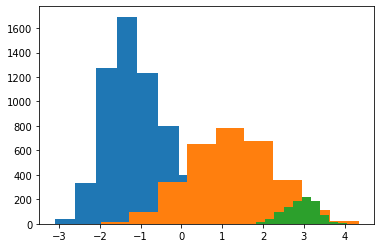

In [29]:
plt.hist(prova[0])
plt.hist(prova[1])
plt.hist(prova[2])
plt.show()

## VP012

In [30]:
file_clust = r.TFile("Cluster_GSI1_cuts.root", "READ")

cluster_v1 = file_clust.Get("cluster_v1")

file_pca = r.TFile("PCA_012.root", "RECREATE")

campione_pca = cluster_v1.CopyTree("k1 >=1 && k2>= 2")
campione_pca.Write("pca")

file_pca.Close()

In [31]:
file_clust.Close()

In [32]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_012.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [33]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI1/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [34]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [35]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR012")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_012")

369

In [36]:
fit_func2 = r.TF1("fit_func2", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -3.5, 5.5)

fit_func2.SetParameters(120, -1.5, .5, 60, 0.8, .7, 20, 3.5, 0.3)

fit_func2.SetParLimits(0, 90, 400)
fit_func2.SetParLimits(3, 30, 200)
fit_func2.SetParLimits(6, 10, 35)

fit_func2.SetParLimits(8, 0.001, .9)

In [37]:
r.Math.MinimizerOptions.SetDefaultMinimizer("Minuit")
r.Math.MinimizerOptions.SetDefaultTolerance(1e-10)
r.Math.MinimizerOptions.SetDefaultMaxIterations(200)

In [38]:
pca_1.Draw("VR012>>v123s(75, -4., 7.)", "", "COLZ")

histos = r.gDirectory.Get("v123s")
histos.SetTitle("VP_{012} [k_{1}>=1 && k_{2}>=2]; VP_{012}; Entries")
fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
fit_func.SetParameters(120, -1.5, .5, 60, 0.9, 0.7, 40, 3., 0.5)

#ampiezze
fit_func.SetParLimits(0, 400, 650)
fit_func.SetParLimits(3, 100, 350)
fit_func.SetParLimits(6, 100, 250)

#punto medio
fit_func.SetParLimits(1, -1.4, -1.)
fit_func.SetParLimits(4, -1, 2.)
fit_func.SetParLimits(7, 2., 4.)

#deviazione_st
fit_func.SetParLimits(2, 0., 2.5)
fit_func.SetParLimits(5, 0.2, 2)
fit_func.SetParLimits(8, 0.3, 2.5)

tr = -1.65

histos.Fit("fit_func", "S", "", tr, 7.)
histos.GetFunction("fit_func").SetLineColor(2)

c = r.TCanvas()
histos.Draw("PE")

params = fit_func.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineColor(95)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)
comp3.Draw("SAME")

legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry(histo, "VR123", "lpe")
legend.AddEntry(fit_func, "Fit")
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z > 3")
legend.AddEntry("testo", "Entries = " + str(histos.GetEntries()), "")
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 4)), "")
legend.Draw("SAME")

t1 = r.TText(4, 200, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


c.Draw()

 FCN=53.6856 FROM MIGRAD    STATUS=CONVERGED     834 CALLS         835 TOTAL
                     EDM=4.52256e-18    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   1.3 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           4.00000e+02   1.63179e+02  -1.17510e-07** at limit **
   2  p1          -1.11249e+00   1.85554e-02  -1.19223e-09  -2.19945e-08
   3  p2           4.42433e-01   2.77231e-02  -3.63135e-09  -1.02976e-07
   4  p3           2.72541e+02   9.83253e+00   1.26493e-08  -3.87918e-08
   5  p4          -1.56636e-01   5.98041e-02  -8.36819e-09  -1.47564e-08
   6  p5           1.30015e+00   4.88261e-02   5.28276e-09  -3.67058e-09
   7  p6           1.64960e+02   7.27874e+00  -2.24128e-09   4.92842e-10
   8  p7           2.63018e+00   2.18634e-02  -2.50004e-10  -1.68942e-07
   9  p8           3.92697e-01   1.91363e-02   2.39573e-09  -9.37901e-08


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [39]:
file_name012 = '012.root'
tup_name012 = '012_c'
prova = make_classification_012_X(pca_1, fit_func, file_name012, tup_name012, 3, tr, 2, 3, 4)

## VP013

In [40]:
file_clust = r.TFile("Cluster_GSI1_cuts.root", "READ")

cluster_v1 = file_clust.Get("cluster_v1")

file_pca = r.TFile("PCA_013.root", "RECREATE")

campione_pca = cluster_v1.CopyTree("k3>=2")
campione_pca.Write("pca")

file_pca.Close()

In [41]:
file_clust.Close()

In [42]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_013.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [43]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI1/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [44]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [45]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR013")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_013")

370

In [46]:
pca_1.Draw("VR013>>v123s(75, -4., 7.)", "", "COLZ")

histos = r.gDirectory.Get("v123s")
histos.SetTitle("VR013; VR013; Conteggi")
fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
fit_func.SetParameters(120, -1.5, .5, 60, 0.9, 0.7, 40, 3., 0.5)

#ampiezze
fit_func.SetParLimits(0, 400, 650)
fit_func.SetParLimits(3, 100, 350)
fit_func.SetParLimits(6, 100, 250)

#punto medio
fit_func.SetParLimits(1, -2.5, -1.)
fit_func.SetParLimits(4, -1, 2.)
fit_func.SetParLimits(7, 2., 4.)

#deviazione_st
fit_func.SetParLimits(2, 0., 2.5)
fit_func.SetParLimits(5, 0.2, 2)
fit_func.SetParLimits(8, 0.3, 2.5)

tr = -1.653

histos.Fit("fit_func", "S", "", tr, 7.)
histos.GetFunction("fit_func").SetLineColor(2)

c = r.TCanvas()
histos.Draw("PE")

params = fit_func.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineColor(6)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)
comp3.Draw("SAME")

legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry(histo, "VR123", "lpe")
legend.AddEntry(fit_func, "Fit")
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z > 3")
legend.AddEntry("testo", "Entries = " + str(histos.GetEntries()))
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()) )
legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 10)))
legend.Draw("SAME")

c.Draw()

 FCN=41.7475 FROM MIGRAD    STATUS=CONVERGED     780 CALLS         781 TOTAL
                     EDM=1.68917e-14    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   3.2 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           4.00000e+02   4.69411e+01  -0.00000e+00** at limit **
   2  p1          -1.16674e+00   2.28103e-02   0.00000e+00  -1.23356e-06
   3  p2           4.70202e-01   3.40583e-02  -0.00000e+00   4.42583e-06
   4  p3           2.68298e+02   1.31337e+01   0.00000e+00   2.35124e-06
   5  p4          -1.17767e-01   5.62287e-02  -0.00000e+00   6.30320e-06
   6  p5           1.15978e+00   6.64464e-02   0.00000e+00   7.08124e-06
   7  p6           1.53082e+02   7.61797e+00  -0.00000e+00   2.00702e-06
   8  p7           2.51041e+00   3.34042e-02   0.00000e+00   1.51912e-06
   9  p8           5.03439e-01   2.56466e-02  -0.00000e+00   1.02796e-05


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [47]:
def make_classification_013_X(PCA_tup, fit_func, file_name, tupname, N_gaus=4, tr=-1.5, Z0=2, Z1=3, Z2=4): 
    
    params = fit_func.GetParameters()
    file_pca2 = r.TFile(file_name, "RECREATE")
    low_value, high_value = 0., 0.
    
    pca_2 = r.TNtuple(tupname, "", "VR012:Z_013")
    Z_c = 0.
    cn_s = []
    for i in range(N_gaus+1):
        cn_s.append([])
        
    for track in PCA_tup:
        PCA_value = track.VR013
        
        if (PCA_value>tr):
            cn_s[-1].append(PCA_value)
            Z_c = 11
            pca_2.Fill(PCA_value, Z_c)
            continue
        
        random_number = np.random.uniform(0,1)
        probs = []
        for i in range(N_gaus):
            probs.append(g_func(PCA_value, params[0+int(3*i)], params[1+int(3*i)], params[2+int(3*i)])/fit_func.Eval(PCA_value) )
        o_ps = sorted(probs)
        indexes = []
        for p in probs:
            indexes.append(o_ps.index(p))
        
        if (random_number <= o_ps[0]):
            check = True
            pos = 0
            for j1 in range(len(indexes)):
                if (indexes[j1] == 0): 
                    pos = j1
            for j2 in range(len(indexes)):
                if (j2 != pos and indexes[j2] == 0):
                    check = False
            if (check):
                cn_s[pos].append(PCA_value)
                if (pos == 0):
                    Z_c = Z0
                elif (pos == 1):
                    Z_c = Z1
                elif (pos == 2):
                    Z_c = Z2
                
                
        for k in range(N_gaus-1):
            
            if (k == 0):
                low_value = o_ps[0]
            elif (k == 1):
                low_value = o_ps[0] + o_ps[k]
            elif (k == 2):
                low_value = high_value
            high_value = low_value + o_ps[k+1]
        
            if (k < N_gaus-2):
                if (random_number > low_value and random_number <= high_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 0):
                    	    Z_c = Z0
                        elif (pos == 1):
                            Z_c = Z1
                        elif (pos == 2):
                            Z_c = Z2
                
            elif (k == N_gaus-2):  #funziona per N_gaus = 4
                if (random_number > low_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 0):
                            Z_c = Z0
                        elif (pos == 1):
                            Z_c = Z1
                        elif (pos == 2):
                            Z_c = Z2
    
        
        pca_2.Fill(PCA_value, Z_c)     
    pca_2.Write(tupname)
    file_pca2.Close()
    return cn_s

In [48]:
file_name013 = '013.root'
tup_name013 = '013_c'
prova2 = make_classification_013_X(pca_1, fit_func, file_name013, tup_name013, 3, tr, 2, 3, 4)

## VP01?

In [49]:
file_pca = r.TFile("PCA_01.root", "RECREATE")

frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

cond = " && k1>0 && k2<2 && k3<2"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

## Scrittura Output

In [80]:
file = r.TFile(track_name, "READ")
tracks = file.Get("tracks")

In [81]:
file_name01 = '01.root'
tup_name01 = '01_c'
file_name012 = '012.root'
tup_name012 = '012_c'
file_name123 = '123.root'
tup_name123 = '123_c'
file_name013 = '013.root'
tup_name013 = '013_c'

In [82]:
## Definizione tree in uscita

file_out = r.TFile(outname, "RECREATE")

Z_rec = np.zeros(1, dtype = np.intc)

output_tree = tracks.CloneTree(0)

#tracks.SetBranchAddress("n0", Z_rec)
output_tree.Branch("Z", Z_rec, "Z/I")
tracks.BuildIndex("trid")

125374

In [83]:
## tree con variabili di volume

nseg0 = np.zeros(1, dtype = np.intc)
nseg1 = np.zeros(1, dtype = np.intc)
nseg2 = np.zeros(1, dtype = np.intc)
nseg3 = np.zeros(1, dtype = np.intc)

volume0 = np.zeros(1, dtype = np.single)
volume1 = np.zeros(1, dtype = np.single)
volume2 = np.zeros(1, dtype = np.single)
volume3 = np.zeros(1, dtype = np.single)


output_tree2 = tracks.CloneTree(0)
output_tree2.Branch("VR0_av", volume0, "VR0_av/F")
output_tree2.Branch("VR1_av", volume1, "VR1_av/F")
output_tree2.Branch("VR2_av", volume2, "VR2_av/F")
output_tree2.Branch("VR3_av", volume3, "VR3_av/F")

output_tree2.Branch("k0", nseg0, "k0/I")
output_tree2.Branch("k1", nseg1, "k1/I")
output_tree2.Branch("k2", nseg2, "k2/I")
output_tree2.Branch("k3", nseg3, "k3/I")

output_tree2.Branch("Z", Z_rec, "Z/I")


In [84]:
for i in range(tracks.GetEntries()):
    tracks.GetEntry(i)
    k0, k1, k2, k3 = 0, 0, 0, 0
    VR0av, VR1av, VR2av, VR3av = 0, 0, 0, 0
    vr0, vr1, vr2, vr3 = 0, 0, 0, 0
    for s in tracks.s:
        if((s.Plate()-31)%4 - 0 == 0):
            k0+=1
            vr0 += s.Volume()
        if((s.Plate()-31)%4 - 1 == 0):
            k1+=1
            vr1 += s.Volume()   
        if((s.Plate()-31)%4 - 2 == 0):
            k2+=1
            vr2 += s.Volume()
        if((s.Plate()-31)%4 - 3 == 0):
            k3+=1
            vr3 += s.Volume()      
    if(k0!=0):
            VR0av = vr0/k0
    if(k1!=0):
            VR1av = vr1/k1
    if(k2!=0):
            VR2av = vr2/k2
    if(k3!=0):
            VR3av = vr3/k3
            
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = k0, k1, k2, k3
    volume0[0], volume1[0], volume2[0], volume3[0] = VR0av, VR1av, VR2av, VR3av
    
    if (k0<k0_min or VR0av>=25000):
        Z_rec[0] = -5
        
        output_tree.Fill()
        output_tree2.Fill()

In [85]:
output_tree.GetEntries()

6706

In [86]:
#file_out.cd()
#output_tree.Write("tracks")
#output_tree2.Write("tracks")   #con info su VRi_av e ki
#file_out.Close()

In [87]:
count = 0
g1, g2, g3, g4, g5, g6, g7 = 0, 0, 0, 0, 0, 0, 0
for i in range(tracks_2.GetEntries()):
    tracks_2.GetEntry(i)
    tracks.GetEntry(tracks_2.trid)
    frag_cut = (tracks_2.VR0_av >= a2*(1 + np.exp(b2 * tracks_2.tan*tracks_2.tan)))
    cond1 = (tracks_2.k2 <=1 and tracks_2.k3<=1)
    cond11 = tracks_2.k1<=1
    cond2 = tracks_2.VR1_av>0
    cond3 = tracks_2.VR1_av>6000
    cond0 = tracks_2.VR1_av == 0
    cond4 = tracks_2.k2 == 0

    cond_vp123 = (tracks_2.k1>0 and tracks_2.k2>0 and tracks_2.k3>1) or (tracks_2.k1>0 and tracks_2.k2>1 and tracks_2.k3>0)
    cond_vp012 = tracks_2.k1>0 and tracks_2.k2>1 and tracks_2.k3<1
    cond_vp013 = tracks_2.k1>0 and tracks_2.k2<1 and tracks_2.k3>1
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if ((i%10000)==0):
        print("Carica Assegnata a " + str(round(count,2)) + " tracce, su " + str(tracks_2.GetEntries()))

    if (tracks_2.k0<k0_min or tracks_2.VR0_av>=25000):
        continue
    if (frag_cut and cond1 and cond11):
        Z_rec[0] = 1
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g1 = g1 + 1
        continue
    if ((not frag_cut) and cond1 and cond11):
        Z_rec[0] = -1
        #print("Z=" +str(Z_rec))
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g4 = g4 + 1
        continue
    
    if (tracks_2.k1>=2 or tracks_2.k2>=2 or tracks_2.k3>=2):

        if ( frag_cut and (not cond11) and cond1):
            g2 = g2 + 1 
            count = count + 1
            if (tracks_2.VR1_av > c0):
                Z_rec[0] = 2
                #print("Z= "+str(Z_rec))
                output_tree.Fill()
                output_tree2.Fill()
                continue
            else:
                Z_rec[0] = 1
                #print("Z= "+str(Z_rec))
                output_tree.Fill()
                output_tree2.Fill()
                continue

        if (cond_vp123):
            g5 = g5 + 1
            continue
        elif (cond_vp012):
            g6 = g6 + 1
            continue
        elif (cond_vp013):
            g7 = g7 +1
            continue
        else:
            Z_rec[0] = 10
            output_tree.Fill()
            output_tree2.Fill()
            continue
    if (count == 0):
        print("Errore")
    #print("count= " + str(count))
print(g1, g2, g3, g4, g5 ,g6, g7)   

Carica Assegnata a 0 tracce, su 110811
Carica Assegnata a 9804 tracce, su 110811
Carica Assegnata a 18470 tracce, su 110811
Carica Assegnata a 25438 tracce, su 110811
Carica Assegnata a 32552 tracce, su 110811
Carica Assegnata a 42429 tracce, su 110811
Carica Assegnata a 51877 tracce, su 110811
Carica Assegnata a 61442 tracce, su 110811
Carica Assegnata a 71021 tracce, su 110811
Carica Assegnata a 80619 tracce, su 110811
Carica Assegnata a 90170 tracce, su 110811
Carica Assegnata a 99556 tracce, su 110811
23424 4044 0 72893 9968 236 122


In [88]:
print(output_tree.GetEntries())
print(g1+g2+g3+g4+g5+g6+g7)

107191
110687


#### Classificazione 123

In [89]:
file_pca123 = r.TFile(file_name123, "READ")
pca_3 = file_pca123.Get(tup_name123)

file_info_pca123 = r.TFile("PCA_123.root", "READ")
info_pca123 = file_info_pca123.Get("pca")

pca_3.AddFriend(info_pca123)
tracks_2.BuildIndex("trid", "npl")
count3 = 0

for track_123 in pca_3:
    
    trid_to_assign, npl_to_assign = track_123.trid, track_123.npl
    tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
    tracks.GetEntry(tracks_2.trid)
    
    check0 = (track_123.k1>0 and track_123.k2>0 and track_123.k3>1) or (track_123.k1>0 and track_123.k2>1 and track_123.k3>0)
    #check0 = track_123.k2>1 and track_123.k3>1
    check1 = track_123.tan == tracks_2.tan and track_123.k0 == tracks_2.k0 and track_123.VR0_av == tracks_2.VR0_av
    check2 = track_123.k1 == tracks_2.k1 and track_123.VR1_av == tracks_2.VR1_av
    check3 = track_123.k2 == tracks_2.k2 and track_123.VR2_av == tracks_2.VR2_av
    check4 = track_123.k3 == tracks_2.k3 and track_123.VR3_av == tracks_2.VR3_av
    check5 = track_123.nseg == tracks_2.nseg and track_123.npl == tracks_2.npl
    check = check1 and check2 and check3 and check4 and check5 and check0
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if (check):
        Z_rec[0] = int(track_123.Z_c)
        #print(Z_rec)
        output_tree.Fill()
        output_tree2.Fill()
        count3 = count3 +1
    #if (count == 0):
        #print("Error")
        #break
    
    if (count3%1000 == 0):
        print("Carica assegnata a " + str(count+count3) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca123.Close()
file_info_pca123.Close()
print("100%")
print(count3)

Carica assegnata a 101361 tracce, su 110811
Carica assegnata a 102361 tracce, su 110811
Carica assegnata a 103361 tracce, su 110811
Carica assegnata a 104361 tracce, su 110811
Carica assegnata a 105361 tracce, su 110811
Carica assegnata a 106361 tracce, su 110811
Carica assegnata a 107361 tracce, su 110811
Carica assegnata a 108361 tracce, su 110811
Carica assegnata a 109361 tracce, su 110811
100%
9968


### Classificazione 012

In [90]:
file_pca012 = r.TFile(file_name012, "READ")
pca_012 = file_pca012.Get(tup_name012)

file_info_pca012 = r.TFile("PCA_012.root", "READ")
info_pca012 = file_info_pca012.Get("pca")

pca_012.AddFriend(info_pca012)
#tracks_2.BuildIndex("trid", "npl")
count4 = 0

for track_012 in pca_012:
    
    countx = 0
    if (track_012.k2 > 1 and track_012.k3<1):
        trid_to_assign, npl_to_assign = track_012.trid, track_012.npl
        tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
        tracks.GetEntry(tracks_2.trid)
    
        check1 = track_012.tan == tracks_2.tan and track_012.k0 == tracks_2.k0 and track_012.VR0_av == tracks_2.VR0_av
        check2 = track_012.k1 == tracks_2.k1 and track_012.VR1_av == tracks_2.VR1_av
        check3 = track_012.k2 == tracks_2.k2 and track_012.VR2_av == tracks_2.VR2_av
        check4 = track_012.k3 == tracks_2.k3 and track_012.VR3_av == tracks_2.VR3_av
        check5 = track_012.nseg == tracks_2.nseg and track_012.npl == tracks_2.npl
        check = check1 and check2 and check3 and check4 and check5
        
        nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
        volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
        
        if (check and track_012.VR2_av < 8000):
            Z_rec[0] = int(track_012.Z_012) 
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            countx = countx + 1
            count4 = count4 +1
        elif (check and track_012.VR2_av > 8000):
            Z_rec[0] = 11
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            countx = countx + 1
            count4 = count4 +1
        #if (count == 0):
            #print("Error")
            #break
        
        if (count4%100 == 0):
           print("Carica assegnata a " + str(count+count3+count4) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca012.Close()
file_info_pca012.Close()
print("100%")
print(count4)

Carica assegnata a 110429 tracce, su 110811
Carica assegnata a 110529 tracce, su 110811
100%
236


In [91]:
file_pca013 = r.TFile(file_name013, "READ")
pca_013 = file_pca013.Get(tup_name013)

file_info_pca013 = r.TFile("PCA_013.root", "READ")
info_pca013 = file_info_pca013.Get("pca")

pca_013.AddFriend(info_pca013)
#tracks_2.BuildIndex("trid", "npl")
count5 = 0

for track_012 in pca_013:
    
    if (track_012.k3 > 1 and track_012.k2<1):
        trid_to_assign, npl_to_assign = track_012.trid, track_012.npl
        tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
        tracks.GetEntry(tracks_2.trid)
    
        check1 = track_012.tan == tracks_2.tan and track_012.k0 == tracks_2.k0 and track_012.VR0_av == tracks_2.VR0_av
        check2 = track_012.k1 == tracks_2.k1 and track_012.VR1_av == tracks_2.VR1_av
        check3 = track_012.k2 == tracks_2.k2 and track_012.VR2_av == tracks_2.VR2_av
        check4 = track_012.k3 == tracks_2.k3 and track_012.VR3_av == tracks_2.VR3_av
        check5 = track_012.nseg == tracks_2.nseg and track_012.npl == tracks_2.npl
        check = check1 and check2 and check3 and check4 and check5
        
        nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
        volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
        
        if (check):
            Z_rec[0] = int(track_012.Z_013)
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            count5 = count5 +1
        elif (check and track_012.VR2_av > 10000):
            Z_rec[0] = 11
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            count5 = count5 +1
        #if (count == 0):
            #print("Error")
            #break
        
        #if (count5%100 == 0):
           #print("Carica assegnata a " + str(count2+count+count3+count4+count5) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca013.Close()
file_info_pca013.Close()
print("100%")
print(count5)

100%
135


In [92]:
output_tree2.GetEntries()

117530

In [93]:
file_out.cd()
#output_tree.Write("tracks")
output_tree2.Write("tracks")   #con info su VRi_av e ki
file_out.Close()

# Plot Opzionali

In [94]:
file_out_new = r.TFile(outname, "READ")
output_tree = file_out_new.Get("tracks")

In [95]:
output_tree.Draw("s[0].Theta()>>Z5(50)", "Z > 0 && Z<10")
h4 = r.gDirectory.Get("Z5")
N2 = h4.GetEntries()
print(N2)

37600.0


In [96]:
c = r.TCanvas()

output_tree.Draw("s[0].Theta()>>Z1(100, 0, 1)", "Z == 1")
hs = r.THStack("h4s", "")
h1 = r.gDirectory.Get("Z1")
h1.SetFillColor(0)
h1.SetLineWidth(2)
h1.SetLineColor(1)
hs.Add(h1)

output_tree.Draw("s[0].Theta()>>Z2(100, 0, 1)", "Z == 2")
h2 = r.gDirectory.Get("Z2")
h2.SetFillColor(0)
h2.SetLineWidth(2)
h2.SetLineColor(4)
hs.Add(h2)

output_tree.Draw("s[0].Theta()>>Z3(100, 0, 1)", "Z == 3")
h3 = r.gDirectory.Get("Z3")
h3.SetFillColor(0)
h3.SetLineWidth(2)
h3.SetLineColor(95)
hs.Add(h3)

output_tree.Draw("s[0].Theta()>>Z4(100, 0, 1)", "Z == 4")
h4 = r.gDirectory.Get("Z4")
h4.SetFillColor(0)
h4.SetLineWidth(2)
h4.SetLineColor(8)
hs.Add(h4)


hs.SetTitle("Fragments Angular Distribution GSI1 (k_{0}>=" + str(k0_min)+"); tan(#theta); Entries")
hs.Draw("nostack")

legend = r.TLegend(0.55,0.6,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)

def lazy(histo, N):
    return "Entries = "+str(histo.GetEntries()) + " (" + str(round(100*histo.GetEntries()/N, 1)) + "%)}{Mean: "+ str(round(histo.GetMean(), 2)) + ", RMS = "+str(round(histo.GetRMS(),2))+"}"

#N = 34881.0

legend.AddEntry(h1, "#splitline{Z=1, " + lazy(h1, N2))
legend.AddEntry(h2, "#splitline{Z=2, "+ lazy(h2, N2))
legend.AddEntry(h3, "#splitline{Z=3, "+ lazy(h3, N2))
legend.AddEntry(h4, "#splitline{Z=4, "+ lazy(h4, N2))

legend.Draw("SAME")

c.Draw()

In [94]:
PLOTS=1
if (PLOTS==1):
    ##for k0>=1
    multiplier = 1.6
    w, h = int(800*multiplier), int(600*multiplier)

    k = r.TCanvas("c", "c", w, h)
    k.SetLeftMargin(0.13)
    k.SetRightMargin(0.92)
    k.SetBottomMargin(100)
    k.SetWindowSize(w,h)

    output_tree.Draw("s[0].Theta()>>Z1(100, 0, 1)", "Z == 1")
    hs = r.THStack("h4s", "")
    h1 = r.gDirectory.Get("Z1")
    h1.SetFillColor(0)
    h1.SetLineWidth(4)
    h1.SetLineColor(1)
    hs.Add(h1)

    output_tree.Draw("s[0].Theta()>>Z2(100, 0, 1)", "Z == 2")
    h2 = r.gDirectory.Get("Z2")
    h2.SetFillColor(0)
    h2.SetLineWidth(4)
    h2.SetLineColor(4)
    hs.Add(h2)

    output_tree.Draw("s[0].Theta()>>Z3(100, 0, 1)", "Z == 3")
    h3 = r.gDirectory.Get("Z3")
    h3.SetFillColor(0)
    h3.SetLineWidth(4)
    h3.SetLineColor(95)
    hs.Add(h3)

    output_tree.Draw("s[0].Theta()>>Z4(100, 0, 1)", "Z == 4")
    h4 = r.gDirectory.Get("Z4")
    h4.SetFillColor(0)
    h4.SetLineWidth(4)
    h4.SetLineColor(8)
    hs.Add(h4)

    #hs.GetXaxis().SetTitleSize(0.045)
    #hs.GetYaxis().SetTitleSize(0.045)

    hs.SetTitle("; tan(#theta); Entries")
    hs.Draw("nostack")

    legend = r.TLegend(0.55,0.6,0.9,0.9)
    legend.SetTextFont(0)
    legend.SetTextSize(0.1)

    def lazy(histo, N):
        return "(Mean: "+ str(round(histo.GetMean(), 2)) + ", RMS = "+str(round(histo.GetRMS(),2))+")"
        #return "Entries = "+str(histo.GetEntries()) + " (" + str(round(100*histo.GetEntries()/N, 1)) + "%)}{Mean: "+ str(round(histo.GetMean(), 2)) + ", RMS = "+str(round(histo.GetRMS(),2))+"}"

    #N = 34881.0

    legend.AddEntry(h1, "Z=1 " + lazy(h1, N2))
    legend.AddEntry(h2, "Z=2 "+ lazy(h2, N2))
    legend.AddEntry(h3, "Z=3 "+ lazy(h3, N2))
    legend.AddEntry(h4, "Z=4 "+ lazy(h4, N2))

    legend.Draw("SAME")
    
    t1.Draw("SAME")
    k.Draw()


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
